In [1]:
# %%
import json
import time
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np


ROOT = Path("..").resolve()
MASTER_DIR = ROOT / "data" / "master" / "master_lib.mat"


# ------------------------------------------------------------
# MATLAB helpers
# ------------------------------------------------------------
def _resolve(f, x):
    while isinstance(x, h5py.Reference):
        x = f[x][()]
    if isinstance(x, np.ndarray) and x.size == 1:
        return _resolve(f, x.item())
    return x


def _matlab_str(f, x) -> str:
    x = _resolve(f, x)
    arr = np.array(x)
    if arr.dtype == np.uint16:
        return "".join(chr(c) for c in arr.flatten() if c != 0)
    if arr.shape == ():
        return str(arr.item())
    return str(arr)


def _matlab_int(f, x) -> int:
    x = _resolve(f, x)
    arr = np.array(x)
    if arr.shape == ():
        return int(arr.item())
    return int(arr.flatten()[0])


def contour_from_mat(mat_path, *, category, img_id):
    with h5py.File(mat_path, "r") as f:
        rec = f["records"]
        ds_cat = rec["category"]
        ds_id = rec["img_id"]
        ds_contour = rec["contour"]

        idx = None
        for i in range(ds_id.size):
            if _matlab_str(f, ds_cat[i]) == category and _matlab_int(f, ds_id[i]) == int(img_id):
                idx = i
                break

        if idx is None:
            raise ValueError(f"No record found for category='{category}', img_id={img_id}")

        contour = np.array(_resolve(f, ds_contour[idx]))

    if contour.ndim != 2:
        raise ValueError(f"Contour is not 2D, got {contour.shape}")
    if contour.shape[0] == 2 and contour.shape[1] != 2:
        contour = contour.T
    if contour.shape[1] != 2:
        raise ValueError(f"Expected Nx2 contour, got {contour.shape}")

    return contour.astype(np.float64)


# ------------------------------------------------------------
# Contour helpers
# ------------------------------------------------------------
def as_open_unique_contour(c: np.ndarray) -> np.ndarray:
    c = np.asarray(c, dtype=np.float64)
    if c.ndim != 2 or c.shape[1] != 2:
        raise ValueError(f"Expected contour shape (N,2), got {c.shape}")
    if c.shape[0] < 3:
        raise ValueError("Contour too short.")
    if np.allclose(c[0], c[-1]):
        c = c[:-1]
    if c.shape[0] < 3:
        raise ValueError("Contour too short after removing duplicate endpoint.")
    return c


def close_contour_for_plot(c: np.ndarray) -> np.ndarray:
    c = as_open_unique_contour(c)
    return np.vstack([c, c[0]])


def edge_lengths(c: np.ndarray) -> np.ndarray:
    c = as_open_unique_contour(c)
    c_closed = np.vstack([c, c[0]])
    d = np.diff(c_closed, axis=0)
    return np.sqrt((d * d).sum(axis=1))


def wrapped_segment_indices(start_i: int, end_j: int, N: int) -> np.ndarray:
    return (np.arange(int(start_i), int(end_j)) % int(N)).astype(int)


def segment_midpoint_arclength(seg_pts: np.ndarray) -> np.ndarray:
    seg_pts = np.asarray(seg_pts, dtype=np.float64)

    if seg_pts.shape[0] == 1:
        return seg_pts[0].copy()

    diffs = np.diff(seg_pts, axis=0)
    step_len = np.linalg.norm(diffs, axis=1)
    cum = np.concatenate([[0.0], np.cumsum(step_len)])
    total = cum[-1]

    if total <= 1e-12:
        return seg_pts.mean(axis=0)

    half = total / 2.0
    k = int(np.searchsorted(cum, half, side="right") - 1)
    k = int(np.clip(k, 0, len(seg_pts) - 2))

    local_len = step_len[k]
    t = 0.0 if local_len <= 1e-12 else (half - cum[k]) / local_len
    return (1.0 - t) * seg_pts[k] + t * seg_pts[k + 1]


# ------------------------------------------------------------
# Feldman-Singh style turning-angle surprisal
# ------------------------------------------------------------
def turning_angles(c: np.ndarray) -> np.ndarray:
    c = as_open_unique_contour(c)
    N = c.shape[0]

    im1 = np.roll(np.arange(N), 1)
    ip1 = np.roll(np.arange(N), -1)

    v1 = c - c[im1]
    v2 = c[ip1] - c

    n1 = np.linalg.norm(v1, axis=1) + 1e-12
    n2 = np.linalg.norm(v2, axis=1) + 1e-12

    a = v1 / n1[:, None]
    b = v2 / n2[:, None]

    cross = a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0]
    dot = a[:, 0] * b[:, 0] + a[:, 1] * b[:, 1]

    return np.arctan2(cross, dot)


def von_mises_kde_pdf(samples: np.ndarray, queries: np.ndarray, *, kappa: float) -> np.ndarray:
    samples = np.asarray(samples, dtype=np.float64).reshape(-1)
    queries = np.asarray(queries, dtype=np.float64).reshape(-1)

    diff = queries[:, None] - samples[None, :]
    num = np.exp(kappa * np.cos(diff)).mean(axis=1)
    denom = 2.0 * np.pi * np.i0(kappa)

    return num / max(1e-12, denom)


def contour_information_surprisal(c: np.ndarray, *, kappa: float = 25.0, eps: float = 1e-12):
    alpha = turning_angles(c)
    p = von_mises_kde_pdf(alpha, alpha, kappa=float(kappa))
    u = -np.log(np.clip(p, eps, None))
    return alpha, p, u


def select_max_fs_window(c: np.ndarray, u: np.ndarray, *, window_frac: float = 0.25):
    """
    Select the contiguous contour window covering window_frac of the total perimeter
    with the highest integrated FS value.
    """
    c = as_open_unique_contour(c)
    u = np.asarray(u, dtype=np.float64).reshape(-1)

    N = c.shape[0]
    if u.shape[0] != N:
        raise ValueError(f"u must have same length as contour points. got u={u.shape[0]}, c={N}")
    if not (0.0 < window_frac <= 1.0):
        raise ValueError("window_frac must be in (0, 1].")

    ds = edge_lengths(c)
    perimeter = float(ds.sum())
    target_len = float(window_frac) * perimeter

    fs_edges = u * ds

    ds2 = np.concatenate([ds, ds])
    fs2 = np.concatenate([fs_edges, fs_edges])

    best_fs = -np.inf
    best_i = 0
    best_j = 0

    j = 0
    cur_len = 0.0
    cur_fs = 0.0

    for i in range(N):
        if j < i:
            j = i
            cur_len = 0.0
            cur_fs = 0.0

        while j < i + N and cur_len < target_len:
            cur_len += ds2[j]
            cur_fs += fs2[j]
            j += 1

        if cur_len >= target_len and cur_fs > best_fs:
            best_fs = float(cur_fs)
            best_i = int(i)
            best_j = int(j)

        cur_len -= ds2[i]
        cur_fs -= fs2[i]

    covered_len = float(ds2[best_i:best_j].sum())
    covered_frac = covered_len / perimeter if perimeter > 0 else np.nan

    return {
        "start_i": best_i,
        "end_j": best_j,
        "perimeter": perimeter,
        "target_len": target_len,
        "covered_len": covered_len,
        "covered_frac": covered_frac,
        "best_fs_value": float(best_fs),
    }


# ------------------------------------------------------------
# Rectangle helpers
# ------------------------------------------------------------
def build_rotated_rect(cx, cy, w, h, theta) -> np.ndarray:
    hw = 0.5 * float(w)
    hh = 0.5 * float(h)

    corners = np.array([
        [-hw, -hh],
        [ hw, -hh],
        [ hw,  hh],
        [-hw,  hh],
    ], dtype=np.float64)

    ct = np.cos(theta)
    st = np.sin(theta)
    R = np.array([[ct, -st],
                  [st,  ct]], dtype=np.float64)

    return corners @ R.T + np.array([float(cx), float(cy)], dtype=np.float64)


def rect_covers_points_scale(
    seg_pts: np.ndarray,
    center_xy: np.ndarray,
    theta: float,
    base_w: float,
    base_h: float,
    margin: float = 1.02,
) -> float:
    """
    Smallest uniform scale so the rotated rectangle covers all seg_pts.
    """
    ct = np.cos(theta)
    st = np.sin(theta)

    R = np.array([
        [ ct,  st],
        [-st,  ct],
    ], dtype=np.float64)

    local = (seg_pts - center_xy) @ R.T

    max_abs_x = float(np.max(np.abs(local[:, 0]))) if len(local) else 0.0
    max_abs_y = float(np.max(np.abs(local[:, 1]))) if len(local) else 0.0

    need_w = 2.0 * max_abs_x
    need_h = 2.0 * max_abs_y

    s_w = need_w / max(float(base_w), 1e-12)
    s_h = need_h / max(float(base_h), 1e-12)

    return max(1.0, s_w, s_h) * float(margin)


# ------------------------------------------------------------
# Final function
# ------------------------------------------------------------
def add_rect_occluder_cover_max_fs_window_plot_and_save_jsonl(
    mat_path: str | Path,
    *,
    category: str,
    img_id: int,

    # base rectangle size
    occ_w: float = 0.10,
    occ_h: float = 0.06,
    occ_theta_deg: float = 0.0,

    # if True, rectangle is forced to cover the max-FS window
    cover_max_fs_window: bool = True,

    # if False, manual placement is used instead
    occ_cx: float | None = None,
    occ_cy: float | None = None,

    # FS window definition
    fs_window_frac: float = 0.25,
    kde_kappa: float = 25.0,

    # plotting and saving
    jsonl_path: str | Path = "case.jsonl",
    seed: int = 7,
    show: bool = True,
):
    c_raw = contour_from_mat(mat_path, category=category, img_id=img_id)
    c = as_open_unique_contour(c_raw)
    c_plot = close_contour_for_plot(c)

    min_xy = c.min(axis=0)
    max_xy = c.max(axis=0)

    alpha, p, u = contour_information_surprisal(c, kappa=float(kde_kappa))
    fs_win = select_max_fs_window(c, u, window_frac=float(fs_window_frac))

    start_i = int(fs_win["start_i"])
    end_j = int(fs_win["end_j"])
    N = c.shape[0]
    seg_idxs = wrapped_segment_indices(start_i, end_j, N)
    seg_pts = c[seg_idxs]

    if seg_pts.shape[0] == 0:
        raise RuntimeError("Selected max-FS window contains no points.")

    if cover_max_fs_window:
        p_start = c[start_i % N]
        p_end = c[end_j % N]

        center_xy = segment_midpoint_arclength(seg_pts)
        cx = float(center_xy[0])
        cy = float(center_xy[1])

        chord = p_end - p_start
        chord_norm = float(np.linalg.norm(chord))
        base_theta = 0.0 if chord_norm <= 1e-12 else float(np.arctan2(chord[1], chord[0]))
        theta = float(base_theta + np.deg2rad(float(occ_theta_deg)))

        scale = rect_covers_points_scale(
            seg_pts=seg_pts,
            center_xy=center_xy,
            theta=theta,
            base_w=float(occ_w),
            base_h=float(occ_h),
            margin=1.02,
        )

        occ_w_eff = float(occ_w) * float(scale)
        occ_h_eff = float(occ_h) * float(scale)

        placement_meta = {
            "mode": "cover_max_fs_window",
            "center_xy": [float(cx), float(cy)],
            "theta_deg": float(np.rad2deg(theta)),
            "base_size_wh": {"w": float(occ_w), "h": float(occ_h)},
            "applied_size_wh": {"w": float(occ_w_eff), "h": float(occ_h_eff)},
            "applied_scale": float(scale),
            "window_start_xy": p_start.tolist(),
            "window_end_xy": p_end.tolist(),
            "window_indices": seg_idxs.tolist(),
            "orientation_source": "line through max-FS window boundary points",
            "sizing_rule": "minimum uniform scaling to cover selected max-FS window",
        }

    else:
        if occ_cx is None or occ_cy is None:
            raise ValueError("If cover_max_fs_window=False, pass occ_cx and occ_cy.")

        cx = float(occ_cx)
        cy = float(occ_cy)

        pad_x = 0.5 * float(occ_w)
        pad_y = 0.5 * float(occ_h)
        cx = float(np.clip(cx, min_xy[0] + pad_x, max_xy[0] - pad_x))
        cy = float(np.clip(cy, min_xy[1] + pad_y, max_xy[1] - pad_y))

        theta = float(np.deg2rad(float(occ_theta_deg)))
        occ_w_eff = float(occ_w)
        occ_h_eff = float(occ_h)

        placement_meta = {
            "mode": "manual",
            "center_xy": [float(cx), float(cy)],
            "theta_deg": float(np.rad2deg(theta)),
            "applied_size_wh": {"w": float(occ_w_eff), "h": float(occ_h_eff)},
        }

    rect = build_rotated_rect(cx, cy, occ_w_eff, occ_h_eff, theta)

    fig = ax = None
    if show:
        fig, ax = plt.subplots(figsize=(6, 6))

        ax.fill(c_plot[:, 0], c_plot[:, 1], color="black", linewidth=0, zorder=1)

        if seg_pts.shape[0] >= 2:
            ax.plot(seg_pts[:, 0], seg_pts[:, 1], linewidth=3.0, zorder=3)

        ax.fill(rect[:, 0], rect[:, 1], color="#838383", linewidth=0, alpha=1, zorder=4)
        ax.scatter([cx], [cy], s=40, zorder=5)

        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.axis("off")
        ax.set_facecolor("white")

        pad = 0.02
        ax.set_xlim(min_xy[0] - pad, max_xy[0] + pad)
        ax.set_ylim(min_xy[1] + pad, max_xy[1] - pad)

        title = f"Cover max-FS window {int(fs_window_frac * 100)}%"
        ax.set_title(title)
        plt.show()

    row = {
        "ts_utc": time.time(),
        "source_mat": str(mat_path),
        "category": category,
        "img_id": int(img_id),
        "coord_system": "normalized_contour_space",
        "shape_contour_xy": c.tolist(),

        "occluder_rect_xy": rect.tolist(),
        "occluder_rect_wh": {
            "w": float(occ_w_eff),
            "h": float(occ_h_eff),
        },

        "occluder_mode": placement_meta["mode"],
        "seed": int(seed),

        "shape_bounds": {
            "min": min_xy.tolist(),
            "max": max_xy.tolist(),
        },
        "plotting": {"invert_yaxis": True},

        "placement": placement_meta,

        "fs_guided_overlay": {
            "paper_like_basis": "Feldman-Singh style turning-angle surprisal with contour-only KDE",
            "kde_kappa": float(kde_kappa),
            "fs_window_frac": float(fs_window_frac),
            "window_start_i": int(start_i),
            "window_end_j": int(end_j),
            "window_stats": fs_win,
        },
    }

    jsonl_path = Path(jsonl_path)
    jsonl_path.parent.mkdir(parents=True, exist_ok=True)
    with open(jsonl_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\n")

    return row, (fig, ax)


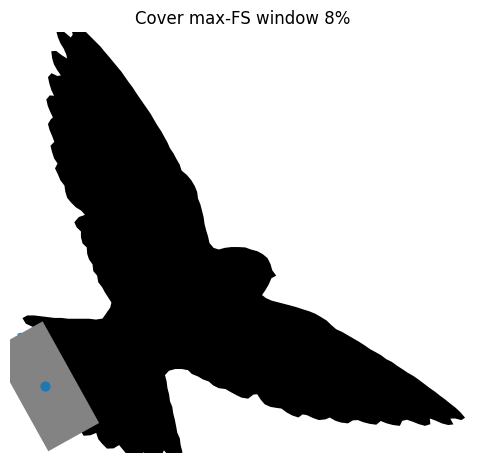

In [9]:
row, _ = add_rect_occluder_cover_max_fs_window_plot_and_save_jsonl(
    MASTER_DIR,
    category="bird",
    img_id=136,
    occ_w=0.05,
    occ_h=0.025,
    occ_theta_deg=0.0,
    cover_max_fs_window=True,
    fs_window_frac=0.08,
    kde_kappa=25.0,
    jsonl_path=ROOT / "data" / "cases" / "sweep" / "bird_136_symmetrical_8_1" / "generated" / "bird_136_symmetrical_8_1.jsonl",
    #jsonl_path=ROOT / "test.jsonl",
    show=True,
)
